In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import numpy.matlib
import numpy.linalg
import csv
from sklearn.preprocessing import KBinsDiscretizer
from collections import defaultdict
from scipy.linalg import eig

In [48]:
#Load in the file data
file_path = "/Users/tapuwa/Desktop/Project5/NOAA_Data_Worcester2.csv"
df_noaa = pd.read_csv(file_path)

In [50]:
df_noaa.head()

,STATION,NAME,DATE,TAVG,TMAX,TMIN
0,USW00094746,"WORCESTER REGIONAL AIRPORT, MA US",1/1/15,20.0,30,13
1,USW00094746,"WORCESTER REGIONAL AIRPORT, MA US",1/2/15,30.0,34,26
2,USW00094746,"WORCESTER REGIONAL AIRPORT, MA US",1/3/15,24.0,30,20
3,USW00094746,"WORCESTER REGIONAL AIRPORT, MA US",1/4/15,34.0,47,30
4,USW00094746,"WORCESTER REGIONAL AIRPORT, MA US",1/5/15,32.0,40,10


In [51]:
df_noaa.tail()

,STATION,NAME,DATE,TAVG,TMAX,TMIN
1456,USW00094746,"WORCESTER REGIONAL AIRPORT, MA US",12/27/18,30.0,35,24
1457,USW00094746,"WORCESTER REGIONAL AIRPORT, MA US",12/28/18,36.0,54,27
1458,USW00094746,"WORCESTER REGIONAL AIRPORT, MA US",12/29/18,45.0,52,28
1459,USW00094746,"WORCESTER REGIONAL AIRPORT, MA US",12/30/18,28.0,33,22
1460,USW00094746,"WORCESTER REGIONAL AIRPORT, MA US",12/31/18,31.0,37,25


In [52]:
df_noaa.shape

(1461, 6)

In [53]:
df_noaa_temps= df_noaa['TAVG']

In [54]:
df_noaa_temps.describe()

count    1460.000000
mean       48.855479
std        18.433522
min        -6.000000
25%        34.000000
50%        50.000000
75%        66.000000
max        81.000000
Name: TAVG, dtype: float64

In [64]:
# Convert the 'DATE' column to datetime format and sort the data
df_noaa['DATE'] = pd.to_datetime(df_noaa['DATE'])

# Define a function to determine the season for a given row in the DataFrame
def get_season(row):
    month = row['DATE'].month
    if 3 <= month <= 5:
        return 'Spring'
    elif 6 <= month <= 8:
        return 'Summer'
    elif 9 <= month <= 11:
        return 'Fall'
    else:
        return 'Winter'

# Apply the function to create a new 'Season' column
df_noaa['Season'] = df_noaa.apply(get_season, axis=1)


In [65]:
# Define temperature bins (example ranges, adjust as needed)
bin_edges = [-10, 0, 10, 20, 30, 40, 50, 60, 70, 80, 90]
num_states = len(bin_edges) - 1


In [66]:
# Function to categorize temperature into states
def check_state(temp, bin_edges):
    for i in range(len(bin_edges) - 1):
        if bin_edges[i] <= temp < bin_edges[i + 1]:
            return i
    return len(bin_edges) - 2  # For the upper edge case

# Initialize a dictionary to hold the Markov Chain for each season
markov_chains = {season: np.zeros((num_states, num_states)) for season in ['Spring', 'Summer', 'Fall', 'Winter']}

# Populate the transition matrices
for season in markov_chains.keys():
    season_data = df_noaa[df_noaa['Season'] == season]['TAVG']
    for i in range(len(season_data) - 1):
        current_state = check_state(season_data.iloc[i], bin_edges)
        next_state = check_state(season_data.iloc[i + 1], bin_edges)
        markov_chains[season][current_state, next_state] += 1

# Normalize the transition matrices for each season
for season, matrix in markov_chains.items():
    row_sums = matrix.sum(axis=1, keepdims=True)
    # Avoid division by zero
    markov_chains[season] = np.divide(matrix, row_sums, out=np.zeros_like(matrix), where=row_sums!=0)


In [68]:
# Print the Markov chains for each season
for season, matrix in markov_chains.items():
    print(f"Markov Chain for {season}:")
    print(matrix)
    print("\n")

Markov Chain for Spring:
[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.3        0.7        0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.14705882 0.35294118 0.47058824 0.02941176
  0.         0.         0.         0.        ]
 [0.         0.         0.01176471 0.16470588 0.58823529 0.23529412
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.01041667 0.17708333 0.54166667
  0.22916667 0.03125    0.01041667 0.        ]
 [0.         0.         0.         0.         0.01282051 0.24358974
  0.47435897 0.23076923 0.03846154 0.        ]
 [0.         0.         0.         0.         0.02222222 0.08888889
  0.33333333 0.42222222 0.13333333 0.        ]
 [0.         0.         0.         0.         0.         0.
  0.21052632 0.3157

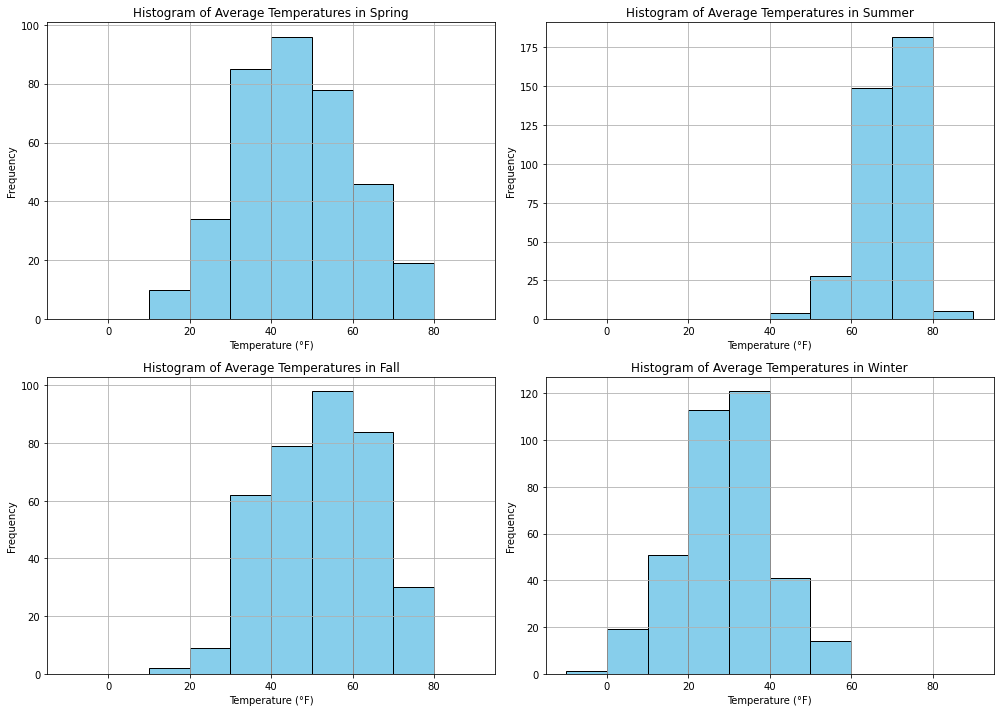

In [67]:
# Define the seasons
seasons = ['Spring', 'Summer', 'Fall', 'Winter']

# Set up the figure to plot multiple histograms
plt.figure(figsize=(14, 10))

# Create a histogram for each season
for i, season in enumerate(seasons, 1):
    plt.subplot(2, 2, i)
    season_temps = df_noaa[df_noaa['Season'] == season]['TAVG']
    plt.hist(season_temps, bins=bin_edges, color='skyblue', edgecolor='black')
    plt.title(f'Histogram of Average Temperatures in {season}')
    plt.xlabel('Temperature (°F)')
    plt.ylabel('Frequency')
    plt.grid(True)

# Adjust the layout
plt.tight_layout()
plt.show()


In [69]:
# Initial state
current_state = np.random.choice(range(len(pMatrix)))

# Number of time steps
num_steps = 10

# Simulate the Markov chain
chain = [current_state]
for _ in range(num_steps - 1):
    current_state = np.random.choice(range(len(pMatrix[current_state])), p=pMatrix[current_state])
    chain.append(current_state)

print("Simulated Markov Chain:", chain)


Simulated Markov Chain: [1, 2, 3, 4, 4, 5, 5, 5, 5, 4]


In [70]:

# Function to calculate the steady-state distribution of a Markov chain
def get_steady_state_distribution(transition_matrix):
   # Transpose the matrix, because numpy calculates the right eigenvectors
    # Subtract identity matrix and add a row for the sum of probabilities
    adjusted_matrix = np.transpose(transition_matrix) - np.identity(len(transition_matrix))
    adjusted_matrix = np.vstack((adjusted_matrix, np.ones(len(transition_matrix))))
    
    # Adjust the target vector to have one more row for the sum of probabilities
    target_vector = np.zeros(len(transition_matrix) + 1)
    target_vector[-1] = 1  # The sum of probabilities in the steady state is 1
    
    # Solve the system of linear equations
    try:
        steady_state_distribution = np.linalg.lstsq(adjusted_matrix, target_vector, rcond=None)[0]
    except np.linalg.LinAlgError:
        # If the system is not solvable, return a message
        return None
    
    return steady_state_distribution

# Calculate and print the steady-state distributions for each season
for season, matrix in markov_chains.items():
    steady_state = get_steady_state_distribution(matrix)
    if steady_state is not None:
        print(f"Steady-state distribution for {season}:")
        print(steady_state)
        print("\n")
    else:
        print(f"Steady-state distribution for {season} could not be calculated.")
        print("\n")


Steady-state distribution for Spring:
[ 4.56508419e-16 -3.33066907e-16  2.14836183e-02  8.43782856e-02
  2.23546716e-01  2.63013349e-01  2.20496063e-01  1.32257969e-01
  5.48239986e-02 -8.32667268e-17]


Steady-state distribution for Summer:
[-1.57622599e-16  0.00000000e+00 -6.93889390e-17 -4.16333634e-17
  1.38777878e-17  6.81252456e-03  7.15315079e-02  4.07179353e-01
  5.00720555e-01  1.37560592e-02]


Steady-state distribution for Fall:
[ 7.61027583e-17 -2.77555756e-16  5.89070391e-03  2.65081676e-02
  1.79666469e-01  2.23958398e-01  2.68783087e-01  2.22841907e-01
  7.23512684e-02 -2.22044605e-16]


Steady-state distribution for Winter:
[2.75183521e-03 5.22601480e-02 1.40343596e-01 3.10516304e-01
 3.37246187e-01 1.14852364e-01 3.92816344e-02 1.11022302e-16
 1.11022302e-16 2.74793190e-03]




In [71]:
# i will use my one monet as Januray whcih falls in the season of winter 
january_data = df_noaa[(df_noaa['DATE'].dt.month == 1) & (df_noaa['DATE'].dt.year == 2018)]['TAVG']

# Convert the temperatures of January into states
january_states = january_data.apply(lambda temp: check_state(temp, bin_edges))

# Convert the sequence of states into an initial distribution vector for the Markov chain
initial_distribution = np.zeros(num_states)
for state in january_states:
    initial_distribution[state] += 1
initial_distribution /= initial_distribution.sum()  # Normalize the distribution

# Function to predict the next state distribution for h time steps
def predict_next_state(initial_distribution, transition_matrix, h):
    current_distribution = initial_distribution
    for _ in range(h):
        current_distribution = np.dot(current_distribution, transition_matrix)
    return current_distribution

# Predict next state behavior for varying time steps h
time_steps = range(1, 31)  # Assuming we want to predict up to 30 days ahead
predictions = {}

for h in time_steps:
    predictions[h] = predict_next_state(initial_distribution, markov_chains['Winter'], h)

# Print the predicted state distribution after h time steps
for h, distribution in predictions.items():
    print(f"Predicted state distribution after {h} days:")
    print(distribution)
    print("\n")


Predicted state distribution after 1 days:
[0.00316256 0.08223675 0.18401833 0.31883683 0.29404038 0.0858437
 0.02872129 0.         0.         0.00314017]


Predicted state distribution after 2 days:
[0.0036082  0.07000398 0.16775905 0.32002213 0.30843858 0.09686103
 0.03048547 0.         0.         0.00282156]


Predicted state distribution after 3 days:
[0.00328939 0.06375311 0.1578293  0.31747321 0.31920458 0.10282201
 0.03279634 0.         0.         0.00283205]


Predicted state distribution after 4 days:
[0.00309469 0.05967822 0.15178638 0.31540729 0.32564817 0.10684862
 0.03472714 0.         0.         0.0028095 ]


Predicted state distribution after 5 days:
[0.0029762  0.05707969 0.14786538 0.3138954  0.32969677 0.10953308
 0.03616226 0.         0.         0.00279121]


Predicted state distribution after 6 days:
[0.00289932 0.05541215 0.14530097 0.31281446 0.33230081 0.1113203
 0.03717416 0.         0.         0.00277784]


Predicted state distribution after 7 days:
[0.00284904